This project is a weak supervision approach, as we're using the initial cluster-based labels (which are noisy labels) to train the model to predict individual MC labels, and then after predict at the patient level.


# Task 1

## Import Data and Libraries

In [ ]:
!pip install --quiet optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 12.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
# from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_validate
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, roc_curve,auc
import optuna
from sklearn.metrics import make_scorer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_recall_curve, f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/reducedfeatures_data.xlsx')
df.head(5)

,Patient ID,original_shape_Elongation,original_firstorder_Kurtosis,original_firstorder_Skewness,wavelet-LHL_glrlm_RunVariance,wavelet2-LHL_gldm_LargeDependenceEmphasis,wavelet2-LLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LargeDependenceEmphasis,wavelet2-LHL_gldm_DependenceVariance,wavelet2-LHL_glrlm_RunVariance,...,wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis,wavelet2-HHH_firstorder_RootMeanSquared,wavelet2-LLH_firstorder_Kurtosis,wavelet-HHL_glcm_Imc2,wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,original_shape_SphericalDisproportion,wavelet2-HHL_glcm_Idmn,wavelet2-LHH_firstorder_RootMeanSquared,wavelet2-HLL_firstorder_Maximum,Label
0,1,0.661690,2.817688,0.769536,7.257078,3381.734540,3715.077716,3546.818663,634.748331,6.682128,...,4005.210235,0.408974,2.949406,0.231474,0.473838,1.572473,0.983853,0.875074,142.866201,0
1,1,0.750849,2.084800,0.442780,3.137745,2653.808184,1443.697357,2297.305200,616.359443,4.095513,...,32.058217,0.282009,2.790798,0.010531,0.401979,1.178144,0.905124,0.696716,21.693040,0
2,1,0.619781,2.590759,0.384512,7.005413,3551.125894,3568.780890,3342.865490,426.661231,8.535867,...,63032.030205,0.442902,3.211156,0.276207,0.446076,1.615550,0.993054,0.832938,163.039718,0
3,2,0.388733,2.932863,0.738215,2.178815,1564.039548,1370.065913,1839.930320,318.122386,1.939531,...,147.649047,0.330143,3.054401,0.023870,0.399957,1.306885,0.911141,0.727764,22.979554,0
4,2,0.820531,2.814081,0.773252,1.316850,1377.981413,1005.602230,1164.799257,325.473446,1.726775,...,65.872763,0.278449,2.074076,0.016973,0.350459,1.165727,0.906515,0.606753,24.490320,0


Overlap in Patient IDs between train and test sets: set()


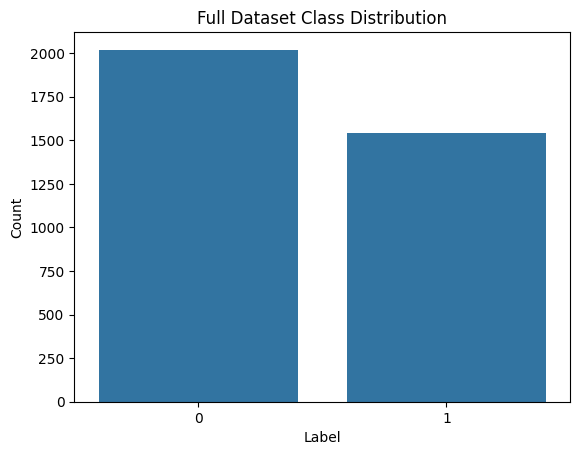

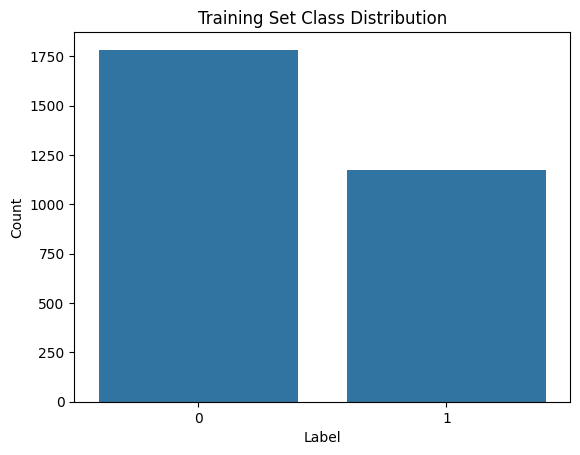

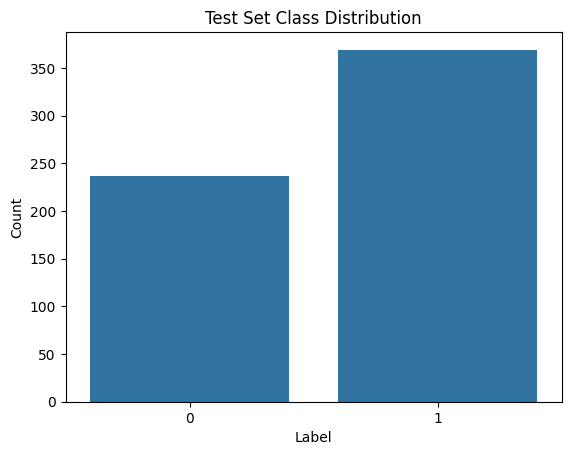

Full Dataset class distribution (proportions):
Label
0    0.567097
1    0.432903
Name: proportion, dtype: float64

Training Set class distribution (proportions):
Label
0    0.60318
1    0.39682
Name: proportion, dtype: float64

Test Set class distribution (proportions):
Label
1    0.608911
0    0.391089
Name: proportion, dtype: float64



In [ ]:
patient_labels = df.groupby('Patient ID')['Label'].max()
train_patients, test_patients = train_test_split(
    patient_labels.index,
    test_size=0.2,
    random_state=42,
    stratify=patient_labels
)

train_df = df[df['Patient ID'].isin(train_patients)].copy()
test_df = df[df['Patient ID'].isin(test_patients)].copy()

# Step 4: Verify no patient overlap between train and test sets
overlap = set(train_df['Patient ID']).intersection(set(test_df['Patient ID']))
print(f"Overlap in Patient IDs between train and test sets: {overlap}")


# Function to plot class distribution
def plot_class_distribution(data, title):
    sns.countplot(x='Label', data=data)
    plt.title(title)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.show()

# Plot distributions
plot_class_distribution(df, 'Full Dataset Class Distribution')
plot_class_distribution(train_df, 'Training Set Class Distribution')
plot_class_distribution(test_df, 'Test Set Class Distribution')


# Function to display class proportions
def display_class_proportions(data, dataset_name):
    proportions = data['Label'].value_counts(normalize=True)
    print(f"{dataset_name} class distribution (proportions):\n{proportions}\n")

# Display proportions
display_class_proportions(df, 'Full Dataset')
display_class_proportions(train_df, 'Training Set')
display_class_proportions(test_df, 'Test Set')



In [ ]:
from sklearn.model_selection import train_test_split

patient_labels = df.groupby('Patient ID')['Label'].max()


# Separate patients by new label
label_0_patients = patient_labels[patient_labels == 0].index
label_1_patients = patient_labels[patient_labels == 1].index

# Stratified manual split
train_0, test_0 = train_test_split(label_0_patients, test_size=0.2, random_state=42)
train_1, test_1 = train_test_split(label_1_patients, test_size=0.2, random_state=42)

# Combine IDs
train_ids = list(train_0) + list(train_1)
test_ids = list(test_0) + list(test_1)

# Split actual data
train_df = df[df['Patient ID'].isin(train_ids)]
test_df = df[df['Patient ID'].isin(test_ids)]

# Check 1: Ensure no patient is in both sets
overlap = set(train_ids) & set(test_ids)
print(f"🔍 Overlapping patients in train and test: {len(overlap)}")  # Should be 0

# Check 2: Class distribution per patient (based on any cancerous MCS)
print("\n📊 Patient label distribution:")
print(patient_labels.value_counts(normalize=True))  # Original label balance

# Check 3: Class distribution in train set
train_patient_labels = patient_labels.loc[train_ids]
print("\n🧪 Train set label distribution:")
print(train_patient_labels.value_counts(normalize=True))

# Check 4: Class distribution in test set
test_patient_labels = patient_labels.loc[test_ids]
print("\n🧪 Test set label distribution:")
print(test_patient_labels.value_counts(normalize=True))



🔍 Overlapping patients in train and test: 0

📊 Patient label distribution:
Label
1    0.520833
0    0.479167
Name: proportion, dtype: float64

🧪 Train set label distribution:
Label
1    0.526316
0    0.473684
Name: proportion, dtype: float64

🧪 Test set label distribution:
Label
0    0.5
1    0.5
Name: proportion, dtype: float64


## Exploratory Data Analysis

### Shape of Data
First, we check the shape of our data to know many examples (rows) and features (columns) we have

In [ ]:
print("The dataframe has {} rows and {} columns".format(df.shape[0], df.shape[1]))

The dataframe has 3562 rows and 152 columns


### Inspect Dataset


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3562 entries, 0 to 3561
Columns: 152 entries, Patient ID to Label
dtypes: float64(150), int64(2)
memory usage: 4.1 MB


In [ ]:
df.isna().sum()

,0
Patient ID,0
original_shape_Elongation,0
original_firstorder_Kurtosis,0
original_firstorder_Skewness,0
wavelet-LHL_glrlm_RunVariance,0
...,...
original_shape_SphericalDisproportion,0
wavelet2-HHL_glcm_Idmn,0
wavelet2-LHH_firstorder_RootMeanSquared,0
wavelet2-HLL_firstorder_Maximum,0


In [ ]:
unique_id = df['Patient ID'].nunique()
print("Number of  patients:", unique_id)

Number of  patients: 96


In [ ]:
features = df.columns.tolist()
print('we have {0} features \n \n'.format(len(features)))
print('list of features in our dataframe:')
for i in features:
  print(i)

we have 152 features 
 

list of features in our dataframe:
Patient ID
original_shape_Elongation
original_firstorder_Kurtosis
original_firstorder_Skewness
wavelet-LHL_glrlm_RunVariance
wavelet2-LHL_gldm_LargeDependenceEmphasis
wavelet2-LLH_gldm_LargeDependenceEmphasis
wavelet-LHL_gldm_LargeDependenceEmphasis
wavelet2-LHL_gldm_DependenceVariance
wavelet2-LHL_glrlm_RunVariance
wavelet-LHL_glrlm_LongRunEmphasis
wavelet-LHH_glrlm_LongRunEmphasis
wavelet-LHH_glrlm_RunPercentage
wavelet2-LLH_glrlm_RunVariance
wavelet-LHH_glrlm_RunLengthNonUniformityNormalized
wavelet-HHH_glrlm_LongRunEmphasis
wavelet-LHH_glrlm_RunVariance
wavelet2-LLH_glrlm_LongRunEmphasis
wavelet2-LHL_glrlm_LongRunEmphasis
wavelet-HHH_glrlm_RunVariance
wavelet2-LHH_glrlm_LongRunEmphasis
wavelet2-LHH_glrlm_RunPercentage
wavelet-LHL_glrlm_RunPercentage
wavelet-HHH_glrlm_RunLengthNonUniformityNormalized
wavelet2-HHH_glrlm_RunLengthNonUniformityNormalized
wavelet2-HHH_glrlm_RunPercentage
wavelet-LHH_glrlm_LongRunLowGrayLevelEmp

In [ ]:
#viz per patient id

df_sort = df.sort_values(by='Patient ID', ascending=False)
display(df_sort.head(17))

print('count records per patient:', df_sort['Patient ID'].value_counts())

print(df[df['Patient ID']==34])


,Patient ID,original_shape_Elongation,original_firstorder_Kurtosis,original_firstorder_Skewness,wavelet-LHL_glrlm_RunVariance,wavelet2-LHL_gldm_LargeDependenceEmphasis,wavelet2-LLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LargeDependenceEmphasis,wavelet2-LHL_gldm_DependenceVariance,wavelet2-LHL_glrlm_RunVariance,...,wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis,wavelet2-HHH_firstorder_RootMeanSquared,wavelet2-LLH_firstorder_Kurtosis,wavelet-HHL_glcm_Imc2,wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,original_shape_SphericalDisproportion,wavelet2-HHL_glcm_Idmn,wavelet2-LHH_firstorder_RootMeanSquared,wavelet2-HLL_firstorder_Maximum,Label
3560,96,0.624101,2.205947,0.349004,1.626775,921.056338,280.690141,1045.957746,148.842690,1.583895,...,14.416448,0.131801,2.174953,0.072674,0.254557,1.280580,0.895171,0.542009,15.171972,1
3561,96,0.540562,2.317722,0.496575,1.933525,479.796178,393.770701,1347.133758,176.326464,0.912156,...,1.846151,0.994323,2.600714,0.293748,0.419372,1.394285,0.971497,1.223159,162.772856,1
3556,96,0.840524,2.204844,0.497080,11.076427,3081.941112,4550.932388,5424.716467,376.806860,5.010325,...,41.417286,0.323171,2.998815,0.376911,0.201713,1.155592,0.962468,0.394885,94.796535,1
3555,96,0.678623,2.214837,0.497116,6.664226,3812.107853,3825.804188,4236.243979,499.773905,5.987054,...,16.442192,0.317461,3.719417,0.665229,0.435891,1.191942,0.964082,0.777109,172.186226,1
3553,96,0.471336,2.236463,0.462205,3.165546,2082.699422,1744.248555,2500.672447,401.067378,2.851365,...,167.295155,0.169537,3.196047,0.013635,0.184933,1.300037,0.918558,0.365018,27.442926,1
3554,96,0.343971,2.514031,0.551812,2.979621,1516.072000,2605.792000,2252.116000,294.709296,2.113410,...,863.216000,0.253917,2.459233,0.070375,0.441570,1.405359,0.922076,0.755194,28.517480,1
3550,96,0.564673,1.914285,0.354224,10.489786,3728.915270,3604.070028,3919.460749,498.023247,9.877888,...,112.643892,0.105734,2.875304,0.035607,0.254193,1.503936,0.897079,0.459458,19.347635,1
3549,96,0.233682,1.924445,0.278610,18.602764,4489.430412,4362.656223,4735.268498,784.861671,17.680411,...,633.296397,0.292628,3.960605,0.574725,0.349700,1.520896,0.995525,0.633380,322.568422,1
3552,96,0.188313,2.164522,0.498416,2.509629,1544.608911,590.435644,1735.846535,248.252451,2.388764,...,206.023037,0.160765,2.998267,0.061488,0.206958,1.602364,0.939468,0.416959,27.906334,1
3551,96,0.670438,1.892021,0.237762,12.966720,3878.930215,3674.257374,4226.627537,503.520367,10.754208,...,523.138665,0.108409,3.253418,0.038901,0.250386,1.295202,0.896410,0.444677,21.670163,1


count records per patient: Patient ID
34    342
9     141
36    138
71    132
42    129
     ... 
95      3
1       3
91      2
87      1
81      1
Name: count, Length: 96, dtype: int64
      Patient ID  original_shape_Elongation  original_firstorder_Kurtosis  \
1042          34                   0.467712                      2.991467   
1043          34                   0.697701                      2.689918   
1044          34                   0.677003                      2.543108   
1045          34                   0.601272                      2.586183   
1046          34                   0.591339                      2.866415   
...          ...                        ...                           ...   
1379          34                   0.550341                      2.741566   
1380          34                   0.709398                      4.511075   
1381          34                   0.575345                      2.273354   
1382          34                   0.351117 

### Data Distribution
Counting and visualizing classes frequency helps understand data distribution, identify biases, and make informed decisions for analysis and model building.

Label
0    2020
1    1542
Name: count, dtype: int64


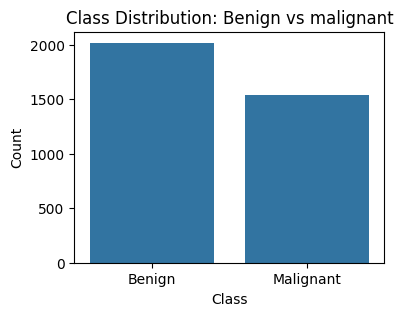

In [ ]:
class_count = df['Label'].value_counts()
print(class_count)
names = {0: 'Benign', 1: 'Malignant'}
plt.figure(figsize=(4, 3))
sns.barplot(x=class_count.index.map(names), y=class_count.values)
plt.title('Class Distribution: Benign vs malignant')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
benign_cases =class_count[0]
malignant_cases =class_count[1]
ratio = benign_cases / malignant_cases
print('ratio is', ratio)

benign_percent = (benign_cases/len(df))*100
malignant_percent = (malignant_cases/len(df))*100
print('benign %: ', benign_percent)
print('malignant %: ', malignant_percent)

ratio is 1.3099870298313878
benign %:  56.70971364402021
malignant %:  43.29028635597979


**Conclusion:**
eventhough the dataset is slightly imbalanced, it is insignificant between the two classes given the ratio of 1.3 to 1 which indicates that for each malignant case there is around 1.3 benign cases. Yet, we can make sure it still doesnt impacct our model's performance by using Stratification when splitting which will preserve the class proportions.

## Data Preparation

in this part we prepare the data before splitting. Any further data-specific analysis will be on the trainining part of the split and the test will not be peaked upon to avoid cheating. Then, if any pre-processing will be done on the data will be done on both splits.

we will also have validation set which will be used to validate models performance during training later on.

### Data Structuring & Split *
given that in data inspection part in EDA we saw that every patient has a different number of MCs and thereby, different number of rows ranging significantly between 1 and 300. looking at similar projects, this could lead to 'Data leakage' where the same patient's MCs or records will be spread over both the training and testing sets of the data after the split.

although such datasets are treated by aggregating the features to have 1 row per patient, I won't be applying that since the information form the characteristics of each row(MC) is needed to be learnt in our task so grouping will only be considered for splitting purposes.

Grouping prior to splitting will be done since rows are not individually independant but belong to different groups - which is the patient in our case. and this is commonly refered to as **repeated measures** data.


*And since order doesn't matter in the instances of each patient, I will use GroupShuffleSplit. - previous unsuccessful attempt as it lead to imbalance of split between test and training*


since splitting withlabel and patient ID was still leading to alot of imbalances, I will reorder(group again but this time by the logic below):
* if a patient has at least 1 cancerous MC -> label is 1 -> Cancerous -> considered label 1 in train/test
* else, label is 0
and this is  done by simply taking the patient label to be the max value of all the grouped MC labels of the same patient.


Train set label distribution:
Label
0    0.531975
1    0.468025
Name: proportion, dtype: float64

Test set label distribution:
Label
0    0.706704
1    0.293296
Name: proportion, dtype: float64


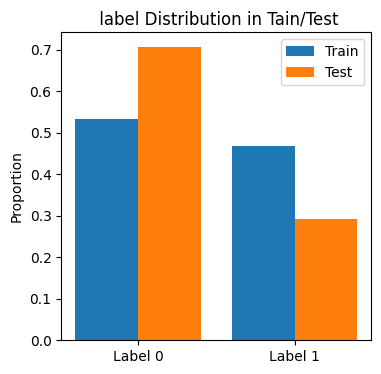

In [ ]:
patient_labels = df.groupby('Patient ID')['Label'].max()

train_patients, test_patients = train_test_split(patient_labels.index, test_size=0.2,random_state=402,stratify=patient_labels)

train_df = df[df['Patient ID'].isin(train_patients)]
test_df = df[df['Patient ID'].isin(test_patients)]

X_train = train_df.drop(columns=['Label', 'Patient ID'])
X_test = test_df.drop(columns=['Label', 'Patient ID'])

y_train = train_df['Label']
y_test = test_df['Label']

#those are dicts!
train_dist = train_df['Label'].value_counts(normalize=True)
test_dist = test_df['Label'].value_counts(normalize=True)

print("Train set label distribution:")
print(train_dist)
print("\nTest set label distribution:")
print(test_dist)


train_0 = train_dist.get(0, 0) #get label 0 if not return 0
train_1 = train_dist.get(1, 0)
test_0 = test_dist.get(0, 0)
test_1 = test_dist.get(1, 0)

labels = ['Label 0', 'Label 1']
x = [0, 1]
#shift_bars =[i - 0.2 for i in x]

plt.figure(figsize=(4, 4))
plt.bar([i - 0.2 for i in x], [train_0, train_1], width=0.4, label='Train')
plt.bar([i + 0.2 for i in x], [test_0, test_1], width=0.4, label='Test')
plt.xticks(x, labels)
plt.ylabel('Proportion')
plt.title(' label Distribution in Tain/Test')
plt.legend()
plt.show()



**Observation:**
* The train-test split result is not well stratified. the test set has fewer label 1 cases.this could hurt model evaluation fairness; so a better split is to be made.

*next*: checking proportions on the MC level.

we do that by grouping the MC rows of each patient in the train/test set. then use size() to count the rows

In [ ]:

mcs_count_train = train_df.groupby('Patient ID').size()
print("\n Number of MCS records per patient in the train set:")
#print(mcs_count_train)
for patient, count in mcs_count_train.items():
  print("patient {patient}: {count} records".format(patient=patient, count=count))
print('\n')
print("-------------------")
mcs_count_test = test_df.groupby('Patient ID').size()
print("\n Number of MCS records per patient in the test set:")
#print(mcs_per_patient_test)
for patient, count in mcs_count_test.items():
  print("patient {patient}: {count} records".format(patient=patient, count=count))



 Number of MCS records per patient in the train set:
patient 1: 3 records
patient 2: 16 records
patient 3: 69 records
patient 4: 20 records
patient 5: 77 records
patient 8: 20 records
patient 9: 141 records
patient 10: 30 records
patient 12: 54 records
patient 13: 5 records
patient 14: 15 records
patient 15: 7 records
patient 17: 15 records
patient 18: 17 records
patient 19: 34 records
patient 20: 38 records
patient 21: 8 records
patient 22: 18 records
patient 23: 5 records
patient 24: 9 records
patient 25: 49 records
patient 26: 28 records
patient 28: 60 records
patient 29: 14 records
patient 30: 25 records
patient 32: 24 records
patient 33: 27 records
patient 34: 342 records
patient 35: 3 records
patient 37: 88 records
patient 39: 70 records
patient 40: 8 records
patient 42: 129 records
patient 43: 13 records
patient 44: 7 records
patient 46: 26 records
patient 47: 34 records
patient 48: 96 records
patient 49: 113 records
patient 50: 10 records
patient 51: 31 records
patient 52: 48 

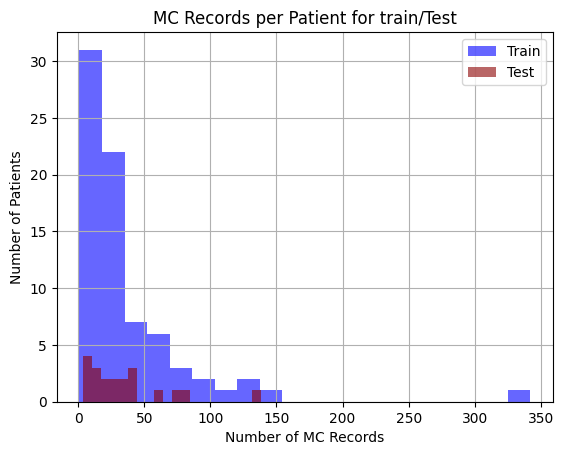

Train skew: 4.038349685484233
Test skew: 1.8670042167632268


In [ ]:
#visual inspection on mc-level after split!

plt.hist(mcs_count_train, bins=20, alpha=0.6, label='Train', color='blue')
plt.hist(mcs_count_test, bins=20, alpha=0.6, label='Test', color='darkred')
plt.title('MC Records per Patient for train/Test')
plt.xlabel('Number of MC Records')
plt.ylabel('Number of Patients')
plt.legend()
plt.grid(True)
plt.show()
print("Train skew:", mcs_count_train.skew())
print("Test skew:", mcs_count_test.skew())

**Obersvation:**
this plot shows the number of patients vs each patient's contributing slices in test and training sets after the split
* the skewed distribution shows that most patients have low number of MCs(rows for the same patient)
* few aptients appear to have high counts especially above 100 MC records or even til 300
* this non-normal distribution is also represented and confirmed by the skewness prited values where :if skew is far from 0 (like >1 or <-1), it's strong evidence of non-normal distribution

**why am I looking at normal distributoin after a fair split by patient ID and label stratisfication?**
because label distribution alone is misleading especially since i used strasify on label.max() level so a patient with 1 Mc is assumed equivalent to a patient with 300 MCs in counts. so although the ppropotions look good, we have hidden skewness. this may bias the model by over-represenation where some patient records will dominate the dataset which ultimately affects fair training and generalization.


 and since in the train_test_split function from scikit-learn, the random_state parameter is used to control the randomness of the data shuffling before splitting it into train and test sets.

**approach to solve**:
to solve this I will test to find the best random state value int he split function to control the shuffling of data before the split happens and thus ensure I get a better and fair distribution at the MC-records level

In [ ]:
for i in range(1,4,1):
  train_patients, test_patients = train_test_split(patient_labels.index, test_size=0.2,random_state=i,stratify=patient_labels)
  train_df = df[df['Patient ID'].isin(train_patients)]
  test_df = df[df['Patient ID'].isin(test_patients)]

  train_dist = train_df['Label'].value_counts(normalize=True)
  test_dist = test_df['Label'].value_counts(normalize=True)

  print('for random state {i}: train data distribution: {train_dist} \n '.format(i=i, train_dist=train_dist))
  print('for random state {i}: test data distribution: {test_dist} \n'.format(i=i, test_dist=test_dist))

  X_train = train_df.drop(columns=['Label', 'Patient ID'])
  X_test = test_df.drop(columns=['Label', 'Patient ID'])

  y_train = train_df['Label']
  y_test = test_df['Label']


for random state 1: train data distribution: Label
0    0.567391
1    0.432609
Name: proportion, dtype: float64 
 
for random state 1: test data distribution: Label
0    0.566085
1    0.433915
Name: proportion, dtype: float64 

for random state 2: train data distribution: Label
0    0.553645
1    0.446355
Name: proportion, dtype: float64 
 
for random state 2: test data distribution: Label
0    0.626911
1    0.373089
Name: proportion, dtype: float64 

for random state 3: train data distribution: Label
0    0.561246
1    0.438754
Name: proportion, dtype: float64 
 
for random state 3: test data distribution: Label
0    0.588312
1    0.411688
Name: proportion, dtype: float64 



In [ ]:
best_rand_value = None
best_difference = float('inf') #init at very high diff

for i in range(1,101,1):
  train_patients, test_patients = train_test_split(patient_labels.index, test_size=0.2,random_state=i,stratify=patient_labels)
  train_df = df[df['Patient ID'].isin(train_patients)]
  test_df = df[df['Patient ID'].isin(test_patients)]

  train_dist = train_df['Label'].value_counts(normalize=True)
  test_dist = test_df['Label'].value_counts(normalize=True)

  #print('for random state {i}: train data distribution: {train_dist} \n'.format(i=i, train_dist=train_dist))
  #print('for random state {i}: test data distribution: {test_dist} \n'.format(i=i, test_dist=test_dist))

  X_train = train_df.drop(columns=['Label', 'Patient ID'])
  X_test = test_df.drop(columns=['Label', 'Patient ID'])
  y_train = train_df['Label']
  y_test = test_df['Label']


  #difference cal
  difference = abs(train_dist.get(1, 0) - test_dist.get(1, 0))
  if difference < best_difference:
    best_difference = difference
    best_rand_value = i

print('best random value with smallest proportional difference: {0}'.format(best_rand_value))

best random value with smallest proportional difference: 75


Train set label distribution:
Label
0    0.567298
1    0.432702
Name: proportion, dtype: float64

Test set label distribution:
Label
0    0.566004
1    0.433996
Name: proportion, dtype: float64


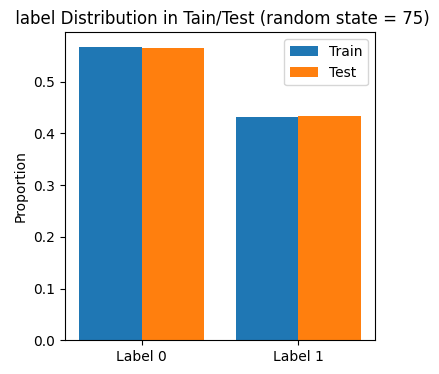

In [ ]:
patient_labels = df.groupby('Patient ID')['Label'].max()

train_patients, test_patients = train_test_split(patient_labels.index, test_size=0.2,random_state=75,stratify=patient_labels)

train_df = df[df['Patient ID'].isin(train_patients)]
test_df = df[df['Patient ID'].isin(test_patients)]

test_df_copy = test_df.copy()

X_train = train_df.drop(columns=['Label', 'Patient ID'])
X_test = test_df.drop(columns=['Label', 'Patient ID'])
y_train = train_df['Label']
y_test = test_df['Label']

train_dist = train_df['Label'].value_counts(normalize=True)
test_dist = test_df['Label'].value_counts(normalize=True)

print("Train set label distribution:")
print(train_dist)
print("\nTest set label distribution:")
print(test_dist)


train_0 = train_dist.get(0, 0) #get label 0 if not return 0
train_1 = train_dist.get(1, 0)
test_0 = test_dist.get(0, 0)
test_1 = test_dist.get(1, 0)

labels = ['Label 0', 'Label 1']
x = [0, 1]
#shift_bars =[i - 0.2 for i in x]

plt.figure(figsize=(4, 4))
plt.bar([i - 0.2 for i in x], [train_0, train_1], width=0.4, label='Train')
plt.bar([i + 0.2 for i in x], [test_0, test_1], width=0.4, label='Test')
plt.xticks(x, labels)
plt.ylabel('Proportion')
plt.title(' label Distribution in Tain/Test (random state = 75)')
plt.legend()
plt.show()



**Observation:**
after loopiong over a range of random states between 0 and 100 and finding the least proportional difference between train and test sets, we got a random state value of 75.

*Result*
as seen in the cell above, using value 75 in the split function resulted in a balanced proportions of 57% label 0, 43% label 1 in both training and testing set.

<!-- *next*: apply a 60/20/20 split to have a validation set in my data.
1. 80% train 20% test
2. split train into 75% train, 25% val (because 0.75 × 80% = 60%, and 0.25 × 80% = 20%) -->

Approach:
I split the data into a stratified train-test split and used Stratified K-Fold cross-validation on the training set instead of a fixed validation split.

why?
to ensure balanced label distribution, avoids over-reliance on a single validation subset, and gives a more reliable estimate of model generalization before final evaluation.


## Feature Engineering

### Multicollinearity
check multi collinearity by computing the correlation matrix between features of the dataframe.

Notes:
- the absolute value of the corelation matrix is taken so that it equally considers + and - values as the sign merely indicates the direction.
- Since we have too many features, I filtered them to assess better by dropping all the correlation values above 0.9

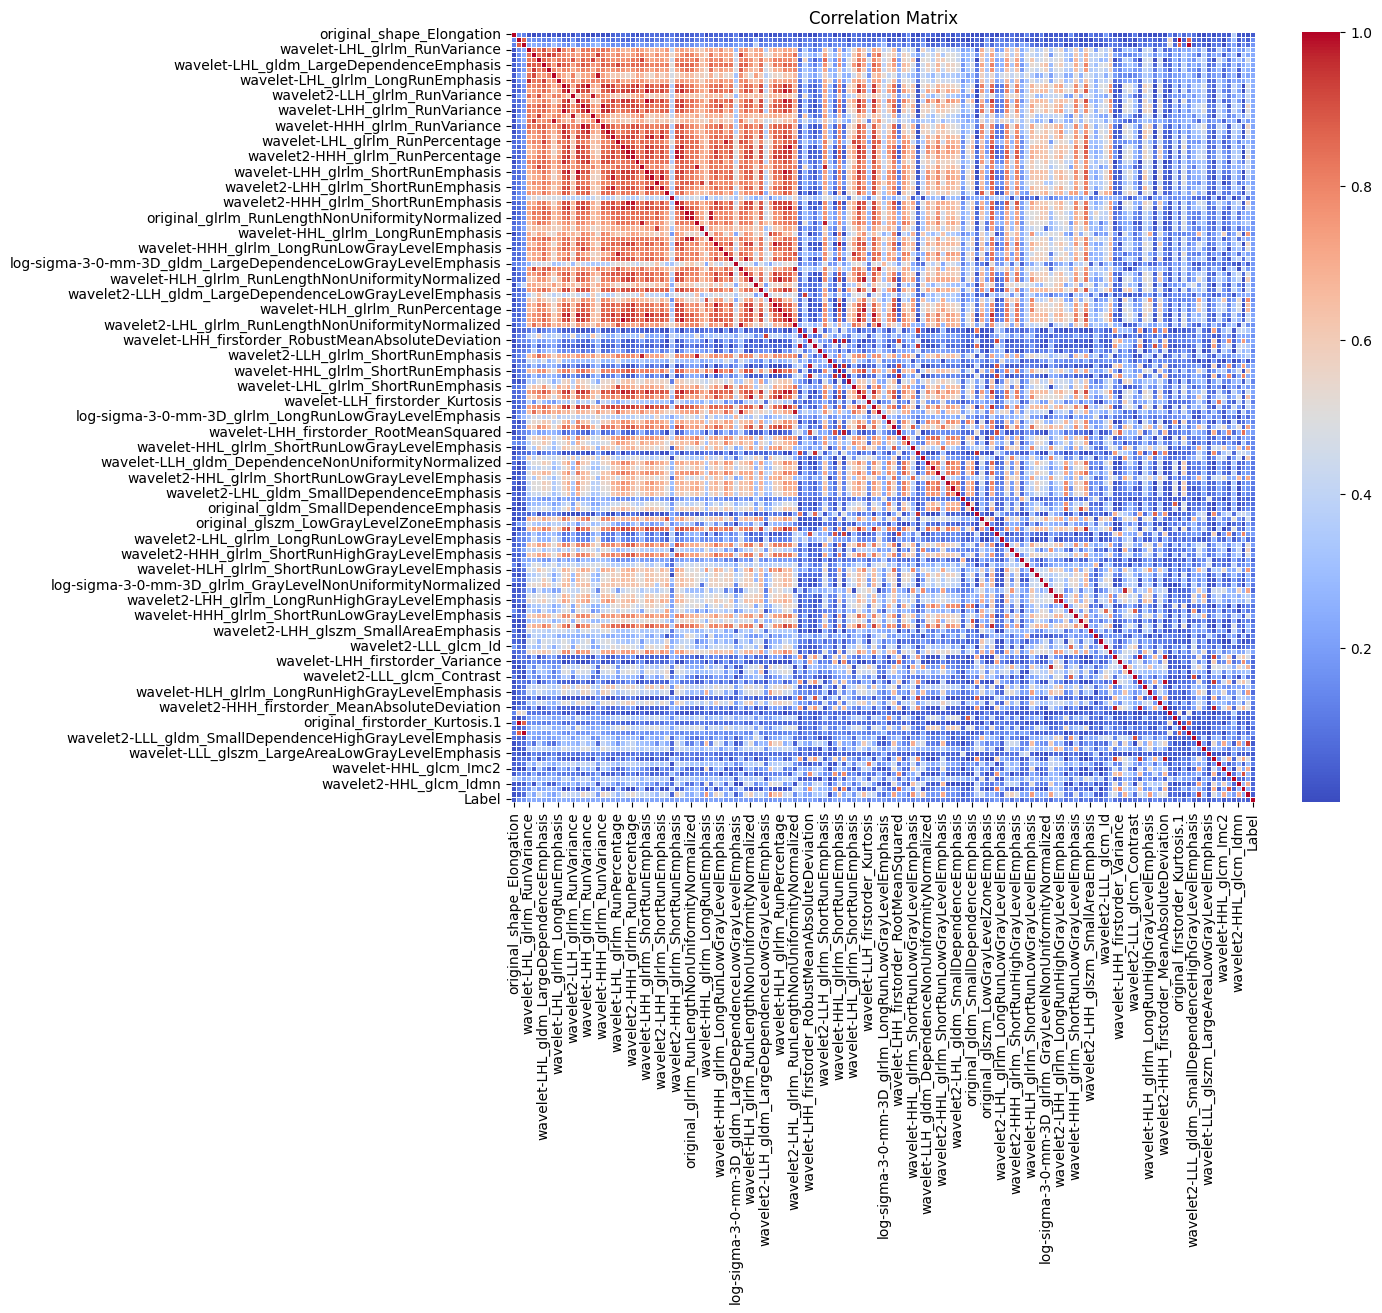

In [ ]:
cordf= train_df.drop(columns=['Patient ID'], axis= 1)

correlation_matrix = cordf.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".2f", annot=False, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:

upper_part =correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
#print(upper_part)
high_corr_features = [col for col in upper_part.columns if any(upper_part[col] >= 0.9)]

#df_cleaned = cordf.drop(columns=high_corr_features)
#df = df.drop(columns=[col for col in high_corr_features if col != 'Patient ID'])
train_df = train_df.drop(columns=[col for col in high_corr_features if col != 'Patient ID'])
train_df = train_df.drop(columns=['Patient ID'])

#but also;
test_df = test_df.drop(columns=[col for col in high_corr_features if col != 'Patient ID'])
test_df = test_df.drop(columns=['Patient ID'])

# val_df = val_df.drop(columns=[col for col in high_corr_features if col != 'Patient ID'])
# val_df = val_df.drop(columns=['Patient ID'])

train_df.head(5)

,original_shape_Elongation,original_firstorder_Kurtosis,original_firstorder_Skewness,wavelet-LHL_glrlm_RunVariance,wavelet2-LHL_gldm_LargeDependenceEmphasis,wavelet2-LLH_gldm_LargeDependenceEmphasis,wavelet-LHL_gldm_LargeDependenceEmphasis,wavelet-LHH_glrlm_LongRunEmphasis,wavelet2-LLH_glrlm_RunVariance,log-sigma-3-0-mm-3D_glrlm_RunPercentage,...,wavelet-LHH_glcm_Imc2,wavelet2-HLL_firstorder_RootMeanSquared,wavelet-HHH_glrlm_LongRunHighGrayLevelEmphasis,wavelet-LLL_glszm_LargeAreaLowGrayLevelEmphasis,wavelet2-LLH_firstorder_Kurtosis,wavelet-HHL_glcm_Imc2,wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation,original_shape_SphericalDisproportion,wavelet2-HHL_glcm_Idmn,Label
0,0.661690,2.817688,0.769536,7.257078,3381.734540,3715.077716,3546.818663,4.906909,7.667752,0.324507,...,0.024131,75.903698,13.110078,4005.210235,2.949406,0.231474,0.473838,1.572473,0.983853,0
1,0.750849,2.084800,0.442780,3.137745,2653.808184,1443.697357,2297.305200,4.090860,2.286657,0.533533,...,0.045284,8.993142,10.093049,32.058217,2.790798,0.010531,0.401979,1.178144,0.905124,0
2,0.619781,2.590759,0.384512,7.005413,3551.125894,3568.780890,3342.865490,6.259312,8.206229,0.159525,...,0.025484,35.960239,15.769474,63032.030205,3.211156,0.276207,0.446076,1.615550,0.993054,0
3,0.388733,2.932863,0.738215,2.178815,1564.039548,1370.065913,1839.930320,3.303002,1.860781,0.622855,...,0.049416,12.599673,8.035637,147.649047,3.054401,0.023870,0.399957,1.306885,0.911141,0
4,0.820531,2.814081,0.773252,1.316850,1377.981413,1005.602230,1164.799257,3.061007,1.444756,0.448133,...,0.058188,12.501247,7.530571,65.872763,2.074076,0.016973,0.350459,1.165727,0.906515,0


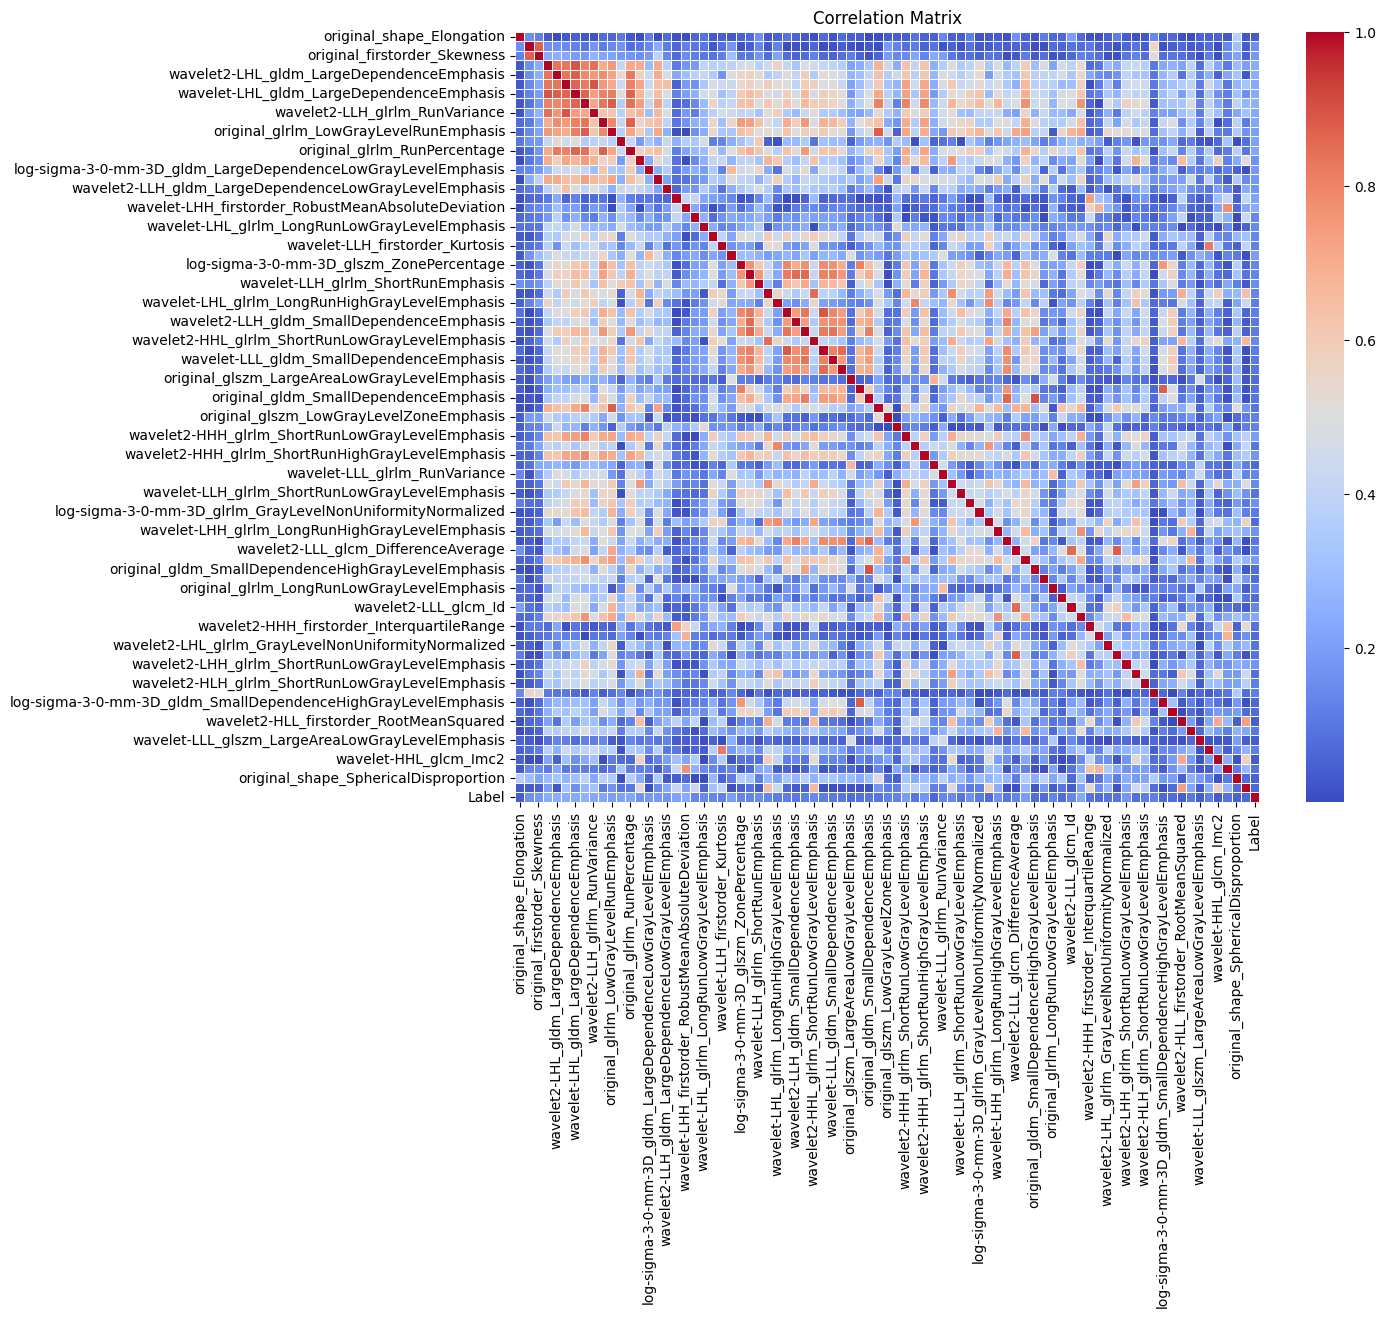

In [ ]:
correlation_matrix_cleaned = train_df.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_cleaned, cmap='coolwarm', fmt=".2f", annot=False, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

**Conslusion:**
After dropping the features that correlates 0.9 higher, we still end up with alot of features of total 81. however, further investigation into those columns will be done to make sure we're not overwhelming the model with redundant features as well as ensuring only distinct and relevant features are used for training. So next I will be assessing the relevancy between the features; becaise looking at the second correlation matrix grid, we still see square-like clusters of colors close to red than others.

**Observation**
At first, before removing Ptient ID which is an irrelevant unique identifier and applying the filtration, the second grid looked better with much less correlations (redness) but then when I removed the column and repeated the step, there appeared alot of correlations thereby hinting to masked correlations hidden before patient ID. therefore, a second filtration step will be done to verify this.

Next: correlation with target variable

### Mutual Information
is great for feature selection in classification tasks with its ability to capture non-linear patterns.it how much knowing one variable reduces uncertainty about another.

where higher MI ==> featureis more useful to predict the target

we can use it from scikit learn library

/tmp/ipython-input-16-3678352678.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_mi.values, y=sorted_mi.index, palette="viridis")


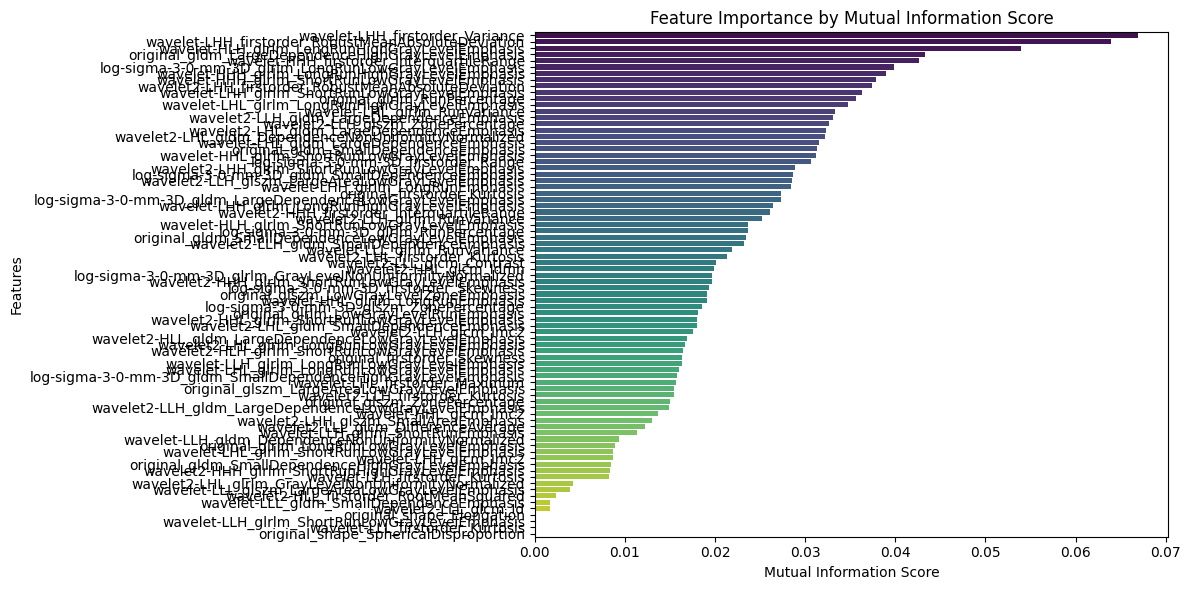

In [ ]:
# df = df_cleaned
X = df.drop('Label', axis= 1)
X_used =train_df.drop('Label', axis= 1)
y = train_df['Label']

mi_values = mutual_info_classif(X_used, y)
mi_series = pd.Series(mi_values, index=X_used.columns)
sorted_mi = mi_series.sort_values(ascending= False)
#print(sorted_mi)
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_mi.values, y=sorted_mi.index, palette="viridis")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Feature Importance by Mutual Information Score")
plt.tight_layout()
plt.show()

80


/tmp/ipython-input-17-1166738825.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_data.values, y=mi_data.index, palette=color_palette)


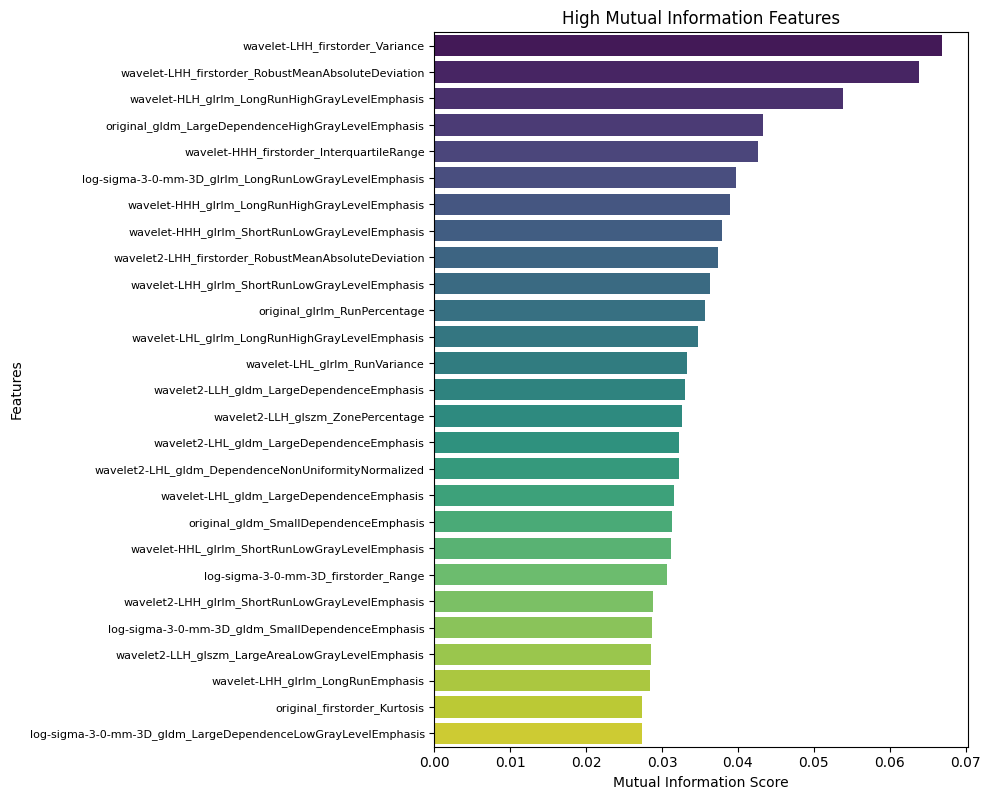

/tmp/ipython-input-17-1166738825.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_data.values, y=mi_data.index, palette=color_palette)


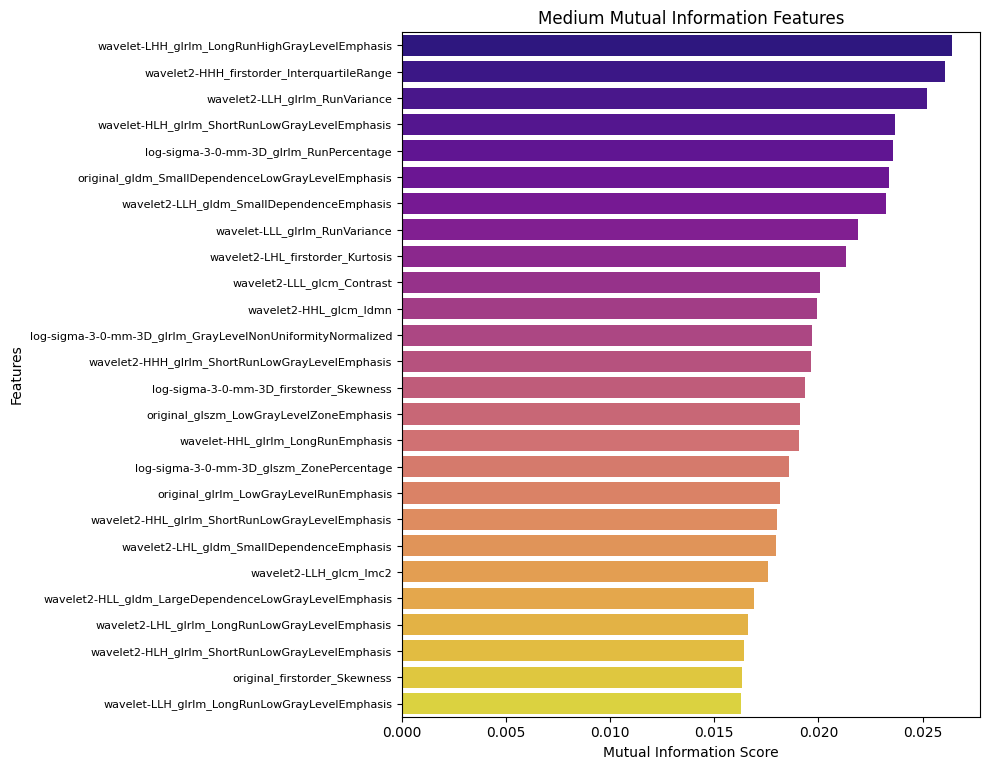

/tmp/ipython-input-17-1166738825.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_data.values, y=mi_data.index, palette=color_palette)


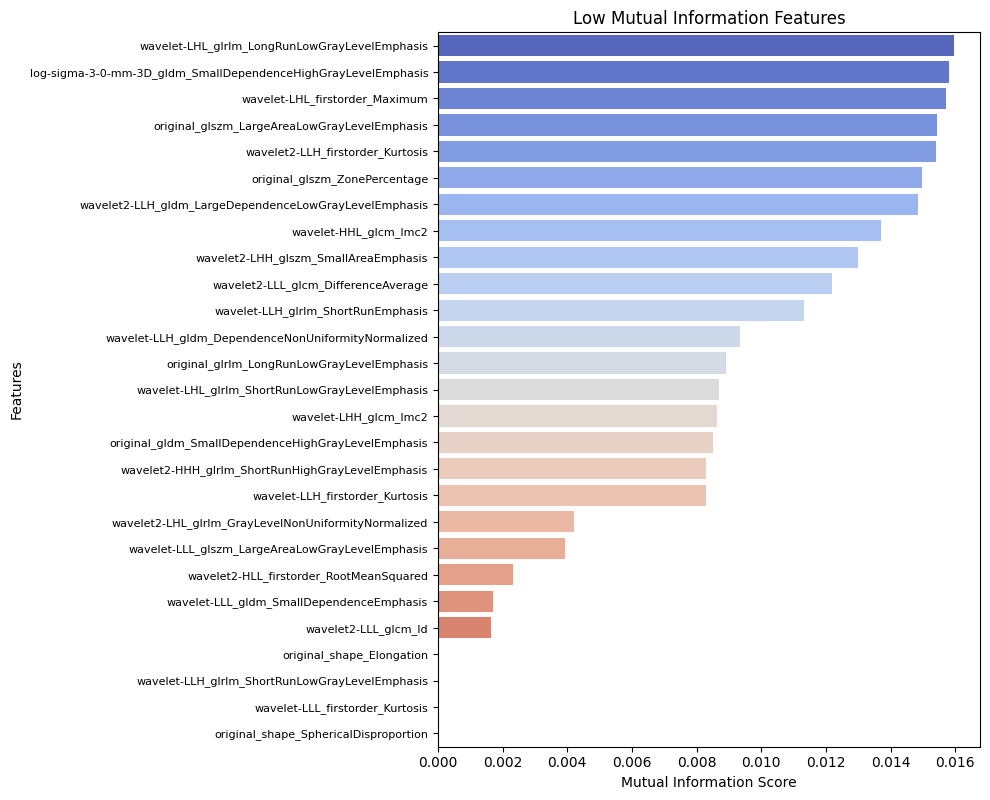

In [ ]:

total_features = len(sorted_mi)
print(total_features)
#thresholds for categorization (adjust based on your data)
high_threshold = sorted_mi.quantile(0.67)  # Top 33% values
low_threshold = sorted_mi.quantile(0.33)   # Bottom 33% values


high_mi = sorted_mi[sorted_mi >= high_threshold]
med_mi = sorted_mi[(sorted_mi < high_threshold) & (sorted_mi > low_threshold)]
low_mi = sorted_mi[sorted_mi <= low_threshold]

# Function to plot MI scores
def plot_mi(mi_data, title, color_palette="viridis"):
    plt.figure(figsize=(10, max(3, len(mi_data) * 0.3)))  # Adjust height dynamically
    sns.barplot(x=mi_data.values, y=mi_data.index, palette=color_palette)
    plt.xlabel("Mutual Information Score")
    plt.ylabel("Features")
    plt.title(title)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

# Plot each category separately
plot_mi(high_mi, "High Mutual Information Features")
plot_mi(med_mi, "Medium Mutual Information Features", color_palette="plasma")
plot_mi(low_mi, "Low Mutual Information Features", color_palette="coolwarm")


58 ['wavelet-LHH_firstorder_Variance', 'wavelet-LHH_firstorder_RobustMeanAbsoluteDeviation', 'wavelet-HLH_glrlm_LongRunHighGrayLevelEmphasis', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'wavelet-HHH_firstorder_InterquartileRange', 'log-sigma-3-0-mm-3D_glrlm_LongRunLowGrayLevelEmphasis', 'wavelet-HHH_glrlm_LongRunHighGrayLevelEmphasis', 'wavelet-HHH_glrlm_ShortRunLowGrayLevelEmphasis', 'wavelet2-LHH_firstorder_RobustMeanAbsoluteDeviation', 'wavelet-LHH_glrlm_ShortRunLowGrayLevelEmphasis', 'original_glrlm_RunPercentage', 'wavelet-LHL_glrlm_LongRunHighGrayLevelEmphasis', 'wavelet-LHL_glrlm_RunVariance', 'wavelet2-LLH_gldm_LargeDependenceEmphasis', 'wavelet2-LLH_glszm_ZonePercentage', 'wavelet2-LHL_gldm_LargeDependenceEmphasis', 'wavelet2-LHL_gldm_DependenceNonUniformityNormalized', 'wavelet-LHL_gldm_LargeDependenceEmphasis', 'original_gldm_SmallDependenceEmphasis', 'wavelet-HHL_glrlm_ShortRunLowGrayLevelEmphasis', 'log-sigma-3-0-mm-3D_firstorder_Range', 'wavelet2-LHH_glrlm_Shor

/tmp/ipython-input-18-3849918818.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_mi.values, y=selected_mi.index, palette="viridis")


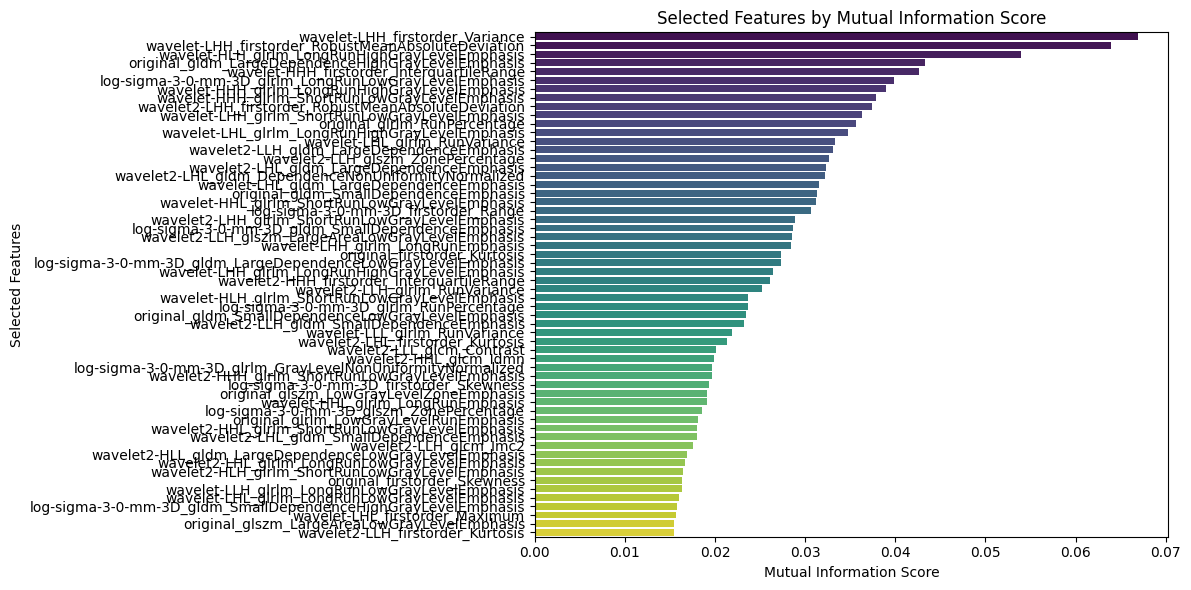

In [ ]:
mi_threshold = 0.015 # 0.020
selected_feat = sorted_mi[sorted_mi >= mi_threshold].index.tolist()
print(len(selected_feat),selected_feat)

selected_mi = sorted_mi[selected_feat].sort_values(ascending= False)
#print(selected_mi)

plt.figure(figsize=(12, 6))
sns.barplot(x=selected_mi.values, y=selected_mi.index, palette="viridis")
plt.xlabel("Mutual Information Score")
plt.ylabel("Selected Features")
plt.title("Selected Features by Mutual Information Score")
plt.tight_layout()
plt.show()

In [ ]:
train_df = df[['Patient ID'] + selected_feat]
len(train_df.columns)

59

**Observatio:**
Looking at the plot for MI, I was unable to use the elbow method because the distribution is smooth and gradually declining without a sharp drop. Instead, I visually selected the MI threshold to be 0.015, which corresponds roughly to the higher side of the **low MI range** based on the *percentile principle* by dividing features into groups by their mutual information scores using quantiles.

Given our relatively small dataset—and considering that with more records MI values might have been higher 0.015 represents a moderate cutoff. After applying this threshold, we are left with 58 features.

*next: this can be further verified upon training and evaluating performance based on the 58 features*

## Data Preprocessing
now apply selection of final features and standardize data

In [ ]:
X_train_selected = X_train[selected_feat]
X_test_selected = X_test[selected_feat]
#X_val_selected = X_val[selected_feat]

scaler = StandardScaler()
scaler.fit(X_train_selected)

X_train_scaled = scaler.transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)
#X_val_scaled = scaler.transform(X_val_selected)


# Training: Classification

also, use validatoin after training sets
This validation process gives information that helps us tune the model’s hyperparameters and configurations accordingly. It is like a critic telling us whether the training is moving in the right direction or not.


to prevent our model from overfitting and be able to generalize well

## Logistic Regression
To start with, logistic regression is a simple model yet a strong baseline for binary classification, it assumes features are independant and linearly related; it is known best for understanding linear trends and building fast and interpretable results.

###why use it?
its a simple model, provides interpreatble probability outcomes and forces us to test if simple linear boundaries is able to separate benign from malignant MCs.

however, this model is sensitive to feature correlation so I will exclusively apply PCA for this model to reduce multicollinearity.(Even after removing highly correlated features from before, the data can still show multicollinearity; especially since shape descriptors remain moderately correlated due to geomety relationships)

### Limitations of Model:
* assumes linear decision is linear: which is an issue if the true class boundary was non-linear
* is sensitive to multicollinearity (which is why PCA is needed to reduce multicollinearity)
* less flexible than other non-linear models which means it could possibly miss complex patterns
* is impacted by unbiased classes (toward the majority class), if not dealt with properly
* not robust to outliers as it can dis proportionately influence model's coefficients


### Feature optimization using  PCA

what PCA (principal component analysis) does is reduce the dimentionality of the features. it transforms what is possibly 'correlated features' into uncorrelated principal components to capture data based on variance.

then set 97% of variance in it to reduce dimensionality while keeping most of the data’s information. It ensures we remove noise and redundancy but still keep the essential patterns for accurate modeling.

In [ ]:
pca = PCA(n_components=0.97)

#for train/test/val
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components selected:", pca.n_components_)

# print(pca.explained_variance_ratio_)


Number of components selected: 38


 Training

### Evaluate baseline model
* use cross-validation to evaluate on training data the baseline performance.

* Even though our previous split leade to balanced classes (56.7% vs 56.6% for class 0), using stratified Cross-validation ensures that every fold of the 5 in the cross-validation maintains this balance

* used cross_validate to be able to get result score on different metrics ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']
in order to have a more reliable evaluation

In [ ]:
logreg = LogisticRegression(random_state=75)

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=75)
scoring = ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

results = cross_validate(logreg, X_train_pca, y_train, cv=strat_kfold, scoring= scoring)

for i in scoring:
  scores = results['test_' + i]
  print(i + ': {:.4f}'.format(scores.mean())) #scores.std()




accuracy: 0.7213
f1: 0.6671
roc_auc: 0.7599
precision: 0.7228
recall: 0.6202


In [ ]:
y_train_np = y_train.to_numpy()

for fold, (train_idx, test_idx) in enumerate(strat_kfold.split(X_train_pca, y_train_np), 1):
    y_train_fold = y_train_np[train_idx]
    unique, counts = np.unique(y_train_fold, return_counts=True)
    print(f" fold {fold} class dist in train: {dict(zip(unique, counts))}")


Fold 1 train class distribution: {np.int64(0): np.int64(1365), np.int64(1): np.int64(1042)}
Fold 2 train class distribution: {np.int64(0): np.int64(1365), np.int64(1): np.int64(1042)}
Fold 3 train class distribution: {np.int64(0): np.int64(1366), np.int64(1): np.int64(1041)}
Fold 4 train class distribution: {np.int64(0): np.int64(1366), np.int64(1): np.int64(1041)}
Fold 5 train class distribution: {np.int64(0): np.int64(1366), np.int64(1): np.int64(1042)}


### Hyper-tuning
hyperparameters are parameters that are **not** directly learnt within estimators. to tune the model, we need to first select the:
* tuning method
* identify the approprite model-specific hyperparameters

after, we evaluate performance of the tuned model.

### Logistic Regression Model hyperparameters:
1. **C**: inverse of regulariation strength It helps control overfitting by penalizing large coefficients. where c is a float number (set to 1 by default)
2. **penalty**: type of regularization. where it could be L1, L2 or elasticnet (its L2 by default)
3. **solver**: is the optimization algorithm used to fit the model.  {"newton-cg", "lbfgs", "liblinear", "sag", "saga"}, default="lbfgs" is an alrogithm to use in the optimization problem. For small datasets, liblinear is a good choice. Sag and saga are faster for large datasets. For multiclass problems, newton-cg, sag, saga and lbfgs are suited better

I will use Grid search to find the best values since we have few hyperparameters to go through.

since my features is likely to still have multicollinearity I'd consider l2 or elasticnet (does feature selection)

since we have a small dataset, then solver='liblinear' is chosen as it also supports l1 and l2




In [ ]:
l1_ratios = np.linspace(0, 1, 21)
C_values = [0.01, 0.05, 0.1, 0.2, 1, 10, 100]

results = []

precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)

for penalty in ['l1', 'l2', 'elasticnet']:
    if penalty == 'elasticnet':
        for C in C_values:
            for l1_ratio in l1_ratios:
                clf = LogisticRegression(penalty=penalty,solver='saga',l1_ratio=l1_ratio,C=C,max_iter=1000,random_state=75)
                cv_results = cross_validate(clf, X_train_pca, y_train, cv=strat_kfold, scoring=scoring, error_score='raise')
                results.append({
                    'penalty': penalty,
                    'C': C,
                    'l1_ratio': l1_ratio,
                    'solver': clf.solver,
                    'Accuracy': cv_results['test_accuracy'].mean(),
                    'Precision': cv_results['test_precision'].mean(),
                    'Recall': cv_results['test_recall'].mean(),
                    'AUC': cv_results['test_roc_auc'].mean(),
                })
    else:
        for C in C_values:
            clf = LogisticRegression(penalty=penalty,solver='liblinear',C=C,max_iter=1000,random_state=75) #class_weight='balanced'
            cv_results = cross_validate(clf, X_train_pca, y_train, cv=strat_kfold, scoring=scoring, error_score='raise')
            results.append({
                'penalty': penalty,
                'C': C,
                'l1_ratio': None,
                'solver': clf.solver,
                'Accuracy': cv_results['test_accuracy'].mean(),
                'Precision': cv_results['test_precision'].mean(),
                'Recall': cv_results['test_recall'].mean(),
                'AUC': cv_results['test_roc_auc'].mean(),
            })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Recall', ascending=False).head(10))

print(results_df.sort_values(by='Accuracy', ascending=False).head(10))

# #   accuracy: 0.7335
# # f1: 0.6663
# # roc_auc: 0.7814
# # precision: 0.7271
# # recall: 0.6152

# #  penalty    C  l1_ratio     solver  Accuracy  Precision    Recall       AUC
# # 146      l2  0.1      0.40  liblinear  0.735132   0.728995  0.617539  0.781221


        penalty      C  l1_ratio     solver  Accuracy  Precision    Recall  \
9            l2    0.1       NaN  liblinear  0.735132   0.728995  0.617539   
10           l2    0.2       NaN  liblinear  0.734801   0.729172  0.616006   
108  elasticnet    1.0      0.50       saga  0.734137   0.727952  0.616001   
109  elasticnet    1.0      0.55       saga  0.734137   0.727952  0.616001   
6            l1  100.0       NaN  liblinear  0.733805   0.727423  0.615995   
13           l2  100.0       NaN  liblinear  0.733805   0.727423  0.615995   
104  elasticnet    1.0      0.30       saga  0.733805   0.727760  0.615231   
107  elasticnet    1.0      0.45       saga  0.733805   0.727702  0.615231   
11           l2    1.0       NaN  liblinear  0.733472   0.727130  0.615231   
103  elasticnet    1.0      0.25       saga  0.733805   0.727760  0.615231   

          AUC  
9    0.781221  
10   0.781421  
108  0.781570  
109  0.781556  
6    0.781329  
13   0.781322  
104  0.781538  
107  0.781552

**obsrvation**

by ordering the same vode by the value of Accuracy, we would've come to choose this configuration by Best accuracy

**penalty L1, C=0.2 and solver=libliner**

where, compared to the baseline model:
* accuracy: increased slightly from 0.7335 to 0.7368
* precision increased from 0.7271 to 0.7348
* **recall decreased from 0.6152 to 0.6129** *--> this is significant especially in medical cases where it shows how many sick patients the model correctly detects*

but a higher recall means fewer missed cases (safer for us in this medical context), while lower recall means more false negatives (riskier). to combat this, I reordered the results by Recall as to find the following configuration:

**penalty: l2 and C: 0.1 solver=libliner**
getting values vs baseline:
* accuracy: increased slightly from 0.7335 to 0.7351
* precision increased from 0.7271 to 0.7290
* **Recall : increased slightly from 0.6152 to 0.6175**


**conclusion**
Both tuned models slightly improved all metrics compared to the baseline, with small trade-offs:

* The L1 tuned model gives the best accuracy and precision but slightly lower recall.

* while the L2-tuned model gives the best recall with slightly lower accuracy and precision than L1 but still better than baseline.

For medical contexts prioritizing recall, the L2-tuned model is preferable, while the L1-tuned model suits cases where accuracy and precision matter more.

### Learning Curve Analysis

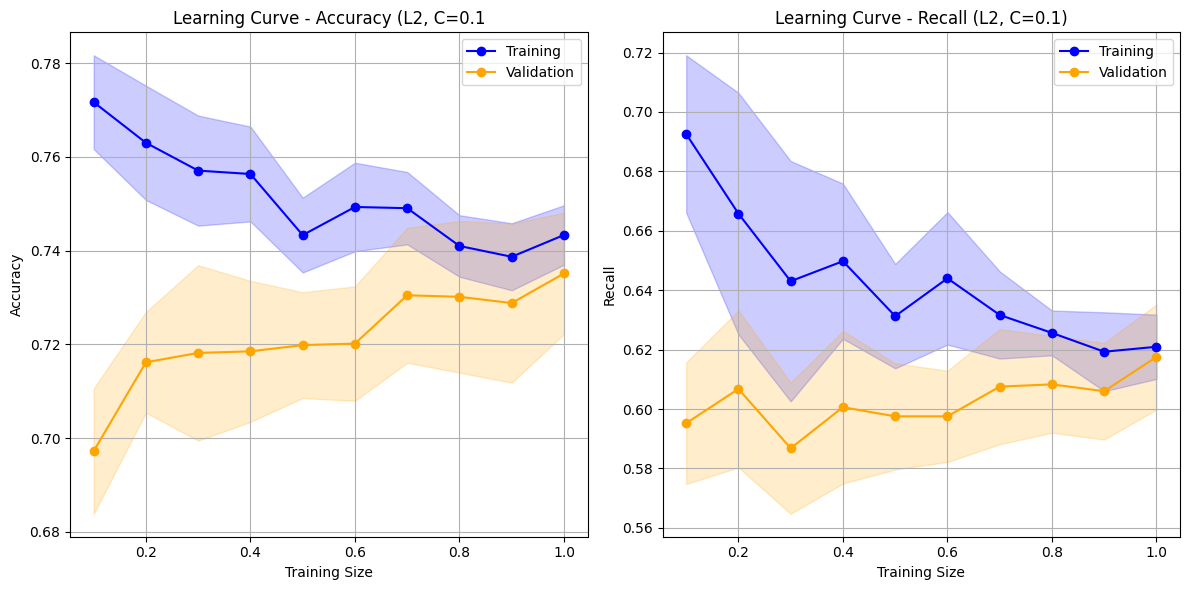

In [ ]:
best_clf = LogisticRegression(penalty='l2', solver='liblinear', C=0.1, max_iter=1000, random_state=75)

train_sizes = np.linspace(0.1, 1.0, 10)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


train_sizes_acc, train_scores_acc, test_scores_acc = learning_curve(
    best_clf, X_train_pca, y_train, cv=strat_kfold, scoring='accuracy',
    train_sizes=train_sizes, n_jobs=-1, shuffle=True, random_state=75)

train_mean = train_scores_acc.mean(axis=1)
train_std = train_scores_acc.std(axis=1)
test_mean = test_scores_acc.mean(axis=1)
test_std = test_scores_acc.std(axis=1)

axes[0].plot(train_sizes, train_mean, 'o-', color='blue', label='Training')
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
axes[0].plot(train_sizes, test_mean, 'o-', color='orange', label='Validation')
axes[0].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='orange')
axes[0].set_title('Learning Curve - Accuracy (L2, C=0.1')
axes[0].set_xlabel('Training Size')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)


train_sizes_rec, train_scores_rec, test_scores_rec = learning_curve(
    best_clf, X_train_pca, y_train,
    cv=strat_kfold, scoring='recall', train_sizes=train_sizes, n_jobs=-1, shuffle=True, random_state=75)

train_mean = train_scores_rec.mean(axis=1)
train_std = train_scores_rec.std(axis=1)
test_mean = test_scores_rec.mean(axis=1)
test_std = test_scores_rec.std(axis=1)

axes[1].plot(train_sizes, train_mean, 'o-', color='blue', label='Training')
axes[1].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')
axes[1].plot(train_sizes, test_mean, 'o-', color='orange', label='Validation')
axes[1].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='orange')
axes[1].set_title('Learning Curve - Recall (L2, C=0.1)')
axes[1].set_xlabel('Training Size')
axes[1].set_ylabel('Recall')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Observation:**

the learning curves plotted as per accuracy and recall help to show us the performance of the model as the training size increase, this can give indications for underfitting (if both scores were low --> very simple model and not learning well) and overfitting (high training score but low validation score --> model is too complex and not learning enough); where a good fit would indicate good generalization where the scores are high and close to eachother.

***in the left plot (accuracy)***:


shows that model starts with high training accuracy and declines steadily slightly with more data; meanwhile the variation accuracy steadily improves efore reaching like a plateau. thus, it indicates that model is learning effectively from data and generalizing well.
note: the consistant gap between the two scores is not large meaning mild overfitting but is under control so the model is still considered reliable.

***in the right plot (recall)***:

shows that th training recall stays steady while validation recall fluctuates more and improves slightly. The wider shaded areas show that recall is less stable, likely due to harder examples or slight class imbalance even after using stratified splits and folds.

notes:

* Gap Between Curves: The gap narrows as training size increases suggesting reduced overfitting and better generalization.

* Confidence Bands: The shaded areas undicate standard deviation. if they shrink with more data indicating more reliable performance estimates.


**conclusion**

So after seeing logistic regressioin best performance after tuning, if recall or overall performance plateaus it makes sense to try more complex models like Random Forests, Gradient Boosting, or Neural Networks which can capture more complex patterns especially when the current model’s learning curves suggest it’s hitting its capacity.



## Random Forest
Random Forest is an algorithm within ensemble methods. The ensemble methods combine the predictions of different estimators to arrive at the final prediction. Random Forest consists of a series of decision trees (estimators). The Random Forest method includes two classes: RandomForestClassifier and RandomForestRegressor. For our current project, we will use RandomForestClassifier. In a classification problem, each tree votes on whether it thinks the cancer scan is malignant (0) or benign (1), and the most popular answer is chosen as the final result.

Advantages:
Low risk of overfitting
Robust against outliers
Works efficiently on large datasets
Has a higher accuracy rating than other algorithms
Disadvantages:
May be biased when dealing with categorical data
Slow workout
Not suitable for linear models with many missing values


in the first, the model assumes a linear relationship which may not be the case since our features is describing complex shapes. random forest is a tree-based model that can handle non-linear relationships as well as feature interactions since it is not sensitive to feature correlation (so doesnt need PCA)

why chosen?
Because it can handle raw, unstructured, and non-linear data while also providing interpretability through feature importance.

### Evaluate baseline Model

note: inthe below i used the scaled values; although as per scikit documentations, it doesn't add any values but is optional.

In [ ]:
rf = RandomForestClassifier(random_state=75)
# rf.fit(X_train, y_train)

In [ ]:
cv_results = cross_validate(rf, X_train_scaled, y_train, cv=strat_kfold,scoring=scoring, error_score='raise')

results = {
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'Recall': cv_results['test_recall'].mean(),
    'AUC': cv_results['test_roc_auc'].mean(),
}

print("Baseline Random Forest Cross val result:")
for metric, value in results.items():
    print(f"{metric}: {value:.3f}")

KeyboardInterrupt: 

### hyper-tuning

same as before but now we set the method and parameters to optimize for ranfom forest:
* parameters:
  1. number of trees (n_estimators) to build in the forest [typical range: 100–1000+]
  2. Maximum Depth of Trees (max_depth)Deeper trees =complex patterns but can overfit [typ range: 10-100]
  3. Minimum Samples to Split (min_samples_split)Min number of samples required to split a node [typ range:20-20]
  4. Minimum Samples per Leaf (min_samples_leaf)Higher values reduce overfitting; lower values allow more detailed splits [1-10]
  5. Number of Features for Split (max_features) num of feat considered for split [for clasification: "auto", "sqrt", "log2"]
  6. Criterion for Splitting (criterion) function [lassification: "gini" or "entropy"]

* method: Bayesian,sicnce Grid search would take longer as this would reply on a probability to find the best values faster. With Optuna (or Bayesian optimization in general), you don’t have to painstakingly define a super fine grid or worry about covering every possible value like in Grid Search.

<!-- n_estimators (100 to 1000) — reasonable range to balance model complexity and runtime.

max_depth (10 to 100) — covers shallow to quite deep trees.

min_samples_split and min_samples_leaf — controlling overfitting nicely.

criterion and max_features — common categorical options to try.

Using cross-validation (cv=strat_kfold) with AUC scoring is great for stable estimates.

n_jobs=-1 to speed things up with parallelism.

60 trials for Optuna is a decent start; you can always increase it later. -->

**approach**:

we define an objective function that given the set of possible hyperparameter combinations, builds and evaluate the model. Inside the function, trial.suggest_ method is used to tell Optuna which hyperparameters to try and their available ranges.

then Optuna creates a case study which aims to maximize the objective returned. optuna runs many 'trials' (i've set it to 60 for better tuning) where Optuma automatically runs the objective function many times to try different hyperparameters; while keeping track of the hyperparameters resulted in the best model. in the end, we get the best hyperparameters of them all.

Optuna uses Bayesian optimization, learning from past trials to smartly balance exploring new values and exploiting promising ones. In the end, we get the best hyperparameters of them all.

In [ ]:
def objective(trial):

    n_estimators = trial.suggest_int('n_estimators', 100, 1000)  # Number of trees
    max_depth = trial.suggest_int('max_depth', 10, 100)         # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)  # Min samples to split
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)   # Min samples per leaf

    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    clf = RandomForestClassifier(
          n_estimators=n_estimators,
          max_depth=max_depth,
          min_samples_split=min_samples_split,
          min_samples_leaf=min_samples_leaf,
          max_features=max_features,
          random_state=75,
          n_jobs=-1
      )


    scores = cross_val_score(clf, X_train_scaled, y_train, cv=strat_kfold, scoring='roc_auc')

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=60)  # you can increase trials for better tuning

print("Best hyperparameters:", study.best_params)
print("Best AUC:", study.best_value)


[I 2025-05-25 13:50:26,980] A new study created in memory with name: no-name-ae49dcc0-5f02-4d9c-bd4f-e477fdde6b43
[I 2025-05-25 13:51:04,369] Trial 0 finished with value: 0.8171316762259915 and parameters: {'n_estimators': 479, 'max_depth': 37, 'min_samples_split': 12, 'min_samples_leaf': 1, 'criterion': 'gini', 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8171316762259915.
[I 2025-05-25 13:51:45,511] Trial 1 finished with value: 0.8156044646179884 and parameters: {'n_estimators': 788, 'max_depth': 73, 'min_samples_split': 13, 'min_samples_leaf': 9, 'criterion': 'gini', 'max_features': 'log2'}. Best is trial 0 with value: 0.8171316762259915.
[I 2025-05-25 13:55:42,056] Trial 2 finished with value: 0.8202554888729587 and parameters: {'n_estimators': 522, 'max_depth': 18, 'min_samples_split': 16, 'min_samples_leaf': 9, 'criterion': 'gini', 'max_features': None}. Best is trial 2 with value: 0.8202554888729587.
[I 2025-05-25 13:56:09,258] Trial 3 finished with value: 0.8177335870

KeyboardInterrupt: 

![Alt text](https://drive.google.com/uc?export=download&id=1RpnGKitMlfsozlSVUEZTTDyWvA6JkHYW)


**Observation**:

til trial 33, we see the best value was reached at trial 32 with 0.8223 however, that isn't significantly higher than that reached at trial 17 with 0.8222. thus, it seems doing the full 60 trials isn't promising to improve since after trial 17 or 32 since even at trial 34 value dropped slightly to 0.8166, while the remaining values are around 0.821 and 0.822--> they're not improving significantly which could indicate that the tuning is plateuing.

so I will stop the tuning early as the trial results would be saved to use further. the result is shown as per the screenshot above.

Trial 32 finished with value: 0.8222961082591667 and parameters:
* 'n_estimators': 886
* 'max_depth': 68
* 'min_samples_split': 6
* 'min_samples_leaf': 4
* 'criterion': 'entropy'
* 'max_features': None

ref:



In [ ]:
best_rf_clf = RandomForestClassifier(n_estimators=886, max_depth=68, min_samples_split=6,min_samples_leaf=4, criterion='entropy', max_features=None, random_state=42)
scores = cross_validate(best_rf_clf, X_train_scaled, y_train, cv=strat_kfold, scoring=scoring, n_jobs=-1)
result = {
    'Accuracy': scores['test_accuracy'].mean(),
    'Precision': scores['test_precision'].mean(),
    'Recall': scores['test_recall'].mean(),
    'AUC': scores['test_roc_auc'].mean(),}

print("Best Random Forest Cross val result after tuning:")
for metric, value in result.items():
    print(f"{metric}: {value:.3f}")



Best Random Forest Cross val result after tuning:
Accuracy: 0.769
Precision: 0.825
Recall: 0.620
AUC: 0.818


**Conclusion**:

after tuning we got the following results vs baseline RF classifier:


* Accuracy:increased slightly from 0.7964 to 0.8067
* **precision: decreased from	0.7682  to 0.7434**
* recall: increased	0.6716 to	0.7537
* roc Auc: increased from 0.7712 to	0.8223
* F1 Score: increased from	0.7162 to	0.7484

eventhough overall, values are better, we notice precision slightly dropped. but it could be due to recall enhancement as a higher recall means finding more positives  which may lead to model being wrong more often. Thus, the tuning process successfully enhanced the model's discriminative power and recall sensitivity; especially given it minimized false negatives much better than log regression


## Multi Layer Perceptron NN
is a type of feed-forward artificial neural network and is made up of multiple layers of neurons. it works by taking the inputs and assignning them with weights, then sums them and use an activation function to make a decision/output. where the weights are adjusted by backpropagation.

it helps to solve complex problem which usually require a non-linear relationships. and has a flexible architecture consisting of:
* inpt layer, n hidden layer, output layer. where every neuron in the hidden layer uses a non linear activation function.

### why use MLP?
* can capture complex petterns
* flexible and can handle complex data inputs or types

### limitaions:
* usually works best on large datasets (unlike ours)
* known to act like a 'black box' --> difficut to interpret
* needs proper and careful tuning of its hyper parameters


note: NN requie standardization so I'll be using X_train_scaled for its a must


### Evaluate baseline model

since we have a small dataset, i will be using scikit-learn’s MLPClassifier which is faster to train. because eventhough tensorflow would allow a more sophisticated architecture, it won't make a huge difference given the small set at hand. also, max iter value of 450 was used cause default (200), 300 and 400 didn't converge

In [ ]:
mlp = MLPClassifier(random_state=75, max_iter=450)

In [ ]:
cv_results = cross_validate(mlp, X_train_scaled, y_train, cv=strat_kfold,scoring=scoring, error_score='raise')
results = {
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'Recall': cv_results['test_recall'].mean(),
    'AUC': cv_results['test_roc_auc'].mean(),
}

print("Baseline MLp NN Cross val result:")
for metric, value in results.items():
    print(f"{metric}: {value:.3f}")

Baseline MLp NN Cross val result:
Accuracy: 0.730
Precision: 0.700
Recall: 0.661
AUC: 0.781


### Hyper-tuning

MLP  Model hyperparameters:

* **hidden_layer_sizes**: number and size of the hidden layers [typ range: ]
* **activation**: function ['relu', 'tanh' or 'logistic']
* **solver**: optimizer that update weights ['adam' by default or'sgd', 'lbfgs']
* **learning rate**: - used in SGD ['constant', 'adaptive', 'invscaling']
* **learning rate_init** : step size [default=0.001]
* **batch size** size of batches [32, 64, 128, or by default 'auto']
* **alpha**: l2 reg to control overfitting [default=0.0001]
* **max iter** for iterations [200,1000]
*  **early stopping** in case of no improvement [True or by default False]

tuning methid to use is Grid search

In [ ]:
# param_grid = {
#     'hidden_layer_sizes': [(64,), (128,), (64, 32)],
#     'activation': ['relu', 'tanh'],
#     'alpha': [0.0001, 0.001, 0.01],
#     'learning_rate_init': [0.001, 0.01],
#     'max_iter': [300],
#     'mlp__solver': ['adam']
# }

pipeline = Pipeline([
    ('mlp', MLPClassifier(random_state=75, early_stopping=True, max_iter=450))
])

parameters_grid ={
        'mlp__hidden_layer_sizes': [(32,), (64,), (128,), (64, 32), (128, 64)],
    'mlp__activation': ['relu', 'tanh', 'logistic'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.001, 0.01],
    'mlp__solver': ['adam','sgd'] ,
    'mlp__max_iter': [300, 500],
    'mlp__early_stopping': [True]
}

scoring = {'accuracy': make_scorer(accuracy_score),'precision': make_scorer(precision_score),'recall': make_scorer(recall_score), 'roc_auc': make_scorer(roc_auc_score)}

grid_search = GridSearchCV(pipeline, parameters_grid, cv= strat_kfold , scoring='roc_auc', n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train)

print("Best parameters are")
print(grid_search.best_params_)

print("\nBest ROC-AUC is:")
print(grid_search.best_score_)


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best parameters are
{'mlp__activation': 'logistic', 'mlp__alpha': 0.0001, 'mlp__early_stopping': True, 'mlp__hidden_layer_sizes': (128, 64), 'mlp__learning_rate_init': 0.01, 'mlp__max_iter': 300, 'mlp__solver': 'adam'}

Best ROC-AUC is:
0.8123462794190501


In [ ]:
best_model = grid_search.best_estimator_
cv_results = cross_validate(best_model, X_train_scaled, y_train, cv=strat_kfold, scoring=scoring, error_score='raise')

results = {
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'Recall': cv_results['test_recall'].mean(),
    'AUC': cv_results['test_roc_auc'].mean(),
}

print("Best MLP result after tuning:")
for metric, value in results.items():
    print(f"{metric}: {value:.3f}")

Best MLP result after tuning:
Accuracy: 0.761
Precision: 0.807
Recall: 0.591
AUC: 0.741


# Testing Winning Model
The test set is a separate set of data used to test the model after completing the training.

It provides an unbiased final model performance metric in terms of all scorings we used to asssess each model with previously.

### Final Conclusion on Model Selection:

random forest showed the best outcome after tuning due to the following:
* Highest Accuracy (77.5%) → thus fewer total errors
* Highest Precision & Recall (81.4%	and 62.4%) → balances false positives & negatives well
* Best AUC (82.5%) → showed to have the best ability to distinguish between classes


### Predict on Test

In [ ]:

best_rf_clf.fit(X_train_scaled, y_train)
y_pred = best_rf_clf.predict(X_test_scaled)
y_proba = best_rf_clf.predict_proba(X_test_scaled)[:, 1]




print("Final Test Set Performance (Random Forest):\n")
print(classification_report(y_test, y_pred, digits=3))


test_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC AUC: {test_auc * 100:.2f}%")


Final Test Set Performance (Random Forest):

              precision    recall  f1-score   support

           0      0.844     0.930     0.885       385
           1      0.831     0.668     0.741       199

    accuracy                          0.841       584
   macro avg      0.838     0.799     0.813       584
weighted avg      0.840     0.841     0.836       584

Test ROC AUC: 88.02%


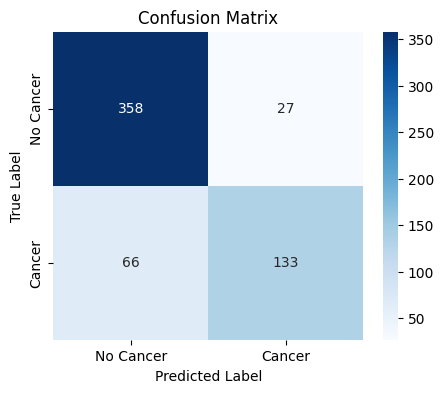

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Cancer', 'Cancer'], yticklabels=['No Cancer', 'Cancer'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
y_proba = best_rf_clf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)


plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (specitivity)')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc

y_proba = best_rf_clf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - specificity)')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
results_df = pd.DataFrame({
    'True Label': y_test,
    'Predicted Label': y_pred
})

print(results_df.head(10))

     True Label  Predicted Label
0             0                0
1             0                0
2             0                1
260           0                0
261           0                0
262           0                0
263           0                0
264           0                0
265           0                0
266           0                0


In [ ]:
#proba
y_proba = best_rf_clf.predict_proba(X_test_scaled)[:, 1]
patient_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Predicted_Prob_Cancer': y_proba
})

# Make a decision using 0.5 threshold
patient_df['Decision'] = (patient_df['Predicted_Prob_Cancer'] >= 0.5).astype(int)

print(patient_df.head())




     True_Label  Predicted_Label  Predicted_Prob_Cancer  Decision
0             0                0               0.266463         0
1             0                0               0.401659         0
2             0                1               0.599964         1
260           0                0               0.487888         0
261           0                0               0.382254         0


# Task 2
Classify whether a subject has cancer or not, based on your classifi
cation of individual MCs of Task 1.

## Patient-level Prediction
Dataframe has features + Patient IDs

Add columns of:
- predicted label per sample
- predicted probability per sample

For each patient:
1. take max predicted probability across samples
2.  classify patient as cancer if max prob ≥ threshold, else non-cancer

*next* Find threshold that maximizes F1 score on patient-level predictions

finally:

Patient decision = highest predicted cancer risk, tuned by best threshold for balanced accuracy

In [ ]:
test_df_copy = test_df.copy()
test_df_copy['Predicted_Label'] = y_pred
test_df_copy['Predicted_Prob_Cancer'] = y_proba
# print(test_df_copy.head(2))

In [ ]:
test_df = test_df.copy()
test_df['Predicted_Label'] = y_pred
test_df['Predicted_Prob_Cancer'] = y_proba

In [ ]:
patient_pred_proba = test_df_copy.groupby('Patient ID')['Predicted_Prob_Cancer'].max()
patient_pred_label = test_df_copy.groupby('Patient ID')['Predicted_Label'].apply(lambda x: x.mode()[0])
patient_final_decision = (patient_pred_proba >= 0.5).astype(int)


patient_true_label = test_df_copy.groupby('Patient ID')['Label'].max()

# add all to 1 df
patient_results = pd.DataFrame({
    'Predicted_Label_MajorityVote': patient_pred_label,
    'Predicted_Prob_Max': patient_pred_proba,
    'Final_Decision_by_Prob_Threshold': patient_final_decision,
    'True_Label': patient_true_label
})
# print(patient_results.head(5))

            Predicted_Label_MajorityVote  Predicted_Prob_Max  \
Patient ID                                                     
1                                      0            0.599964   
7                                      0            0.813308   
8                                      0            0.566375   
9                                      0            0.669479   
18                                     0            0.804860   

            Final_Decision_by_Prob_Threshold  True_Label  
Patient ID                                                
1                                          1           0  
7                                          1           0  
8                                          1           0  
9                                          1           0  
18                                         1           0  


Patient-level Accuracy: 0.7
Patient-level Precision: 0.7
Patient-level Recall: 0.7
Patient-level F1: 0.7


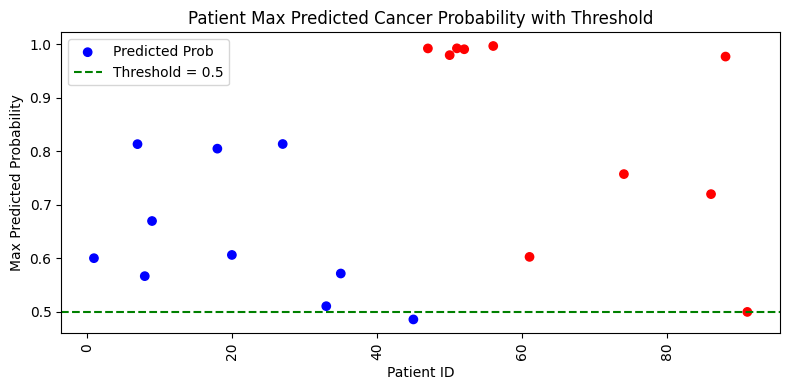

In [ ]:
print("Patient-level Accuracy:", accuracy_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))
print("Patient-level Precision:", precision_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))
print("Patient-level Recall:", recall_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))
print("Patient-level F1:", f1_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))



plt.figure(figsize=(8,4))
plt.scatter(patient_results.index, patient_results['Predicted_Prob_Max'],
            c=patient_results['True_Label'], cmap='bwr', label='Predicted Prob')
plt.axhline(0.5, color='green', linestyle='--', label='Threshold = 0.5')
plt.xlabel('Patient ID')
plt.ylabel('Max Predicted Probability')
plt.title('Patient Max Predicted Cancer Probability with Threshold')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Finding Best Decision Threshold

because the previous guessing threshold didn't result in good metrics. so by finding the best threshold after probability calculations, we can better predict relaibly.

####how?
1. Use predicted probabilities (y_scores) and true labels (y_true) at patient level
2. Calculate precision, recall, and thresholds using precision-recall curve
3. Compute F1 scores for each threshold and then take threshold with the highest F1 as the best one
4. Classify patients as positive if their predicted probability ≥ best threshold; else negative

 then we evalyate our new predictions!

In [ ]:
y_true = patient_results['True_Label']
y_scores = patient_results['Predicted_Prob_Max']

precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

patient_results['Final_Decision_Best_Thresh'] = (y_scores >= best_threshold).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score

print(f"Best threshold: {best_threshold:.3f}")
print(f"Accuracy: {accuracy_score(y_true, patient_results['Final_Decision_Best_Thresh']):.3f}")
print(f"Precision: {precision_score(y_true, patient_results['Final_Decision_Best_Thresh']):.3f}")
print(f"Recall: {recall_score(y_true, patient_results['Final_Decision_Best_Thresh']):.3f}")




Best threshold: 0.720
Accuracy: 0.750
Precision: 0.727
Recall: 0.800


Patient-level Accuracy: 0.7
Patient-level Precision: 0.7
Patient-level Recall: 0.7
Patient-level F1: 0.7


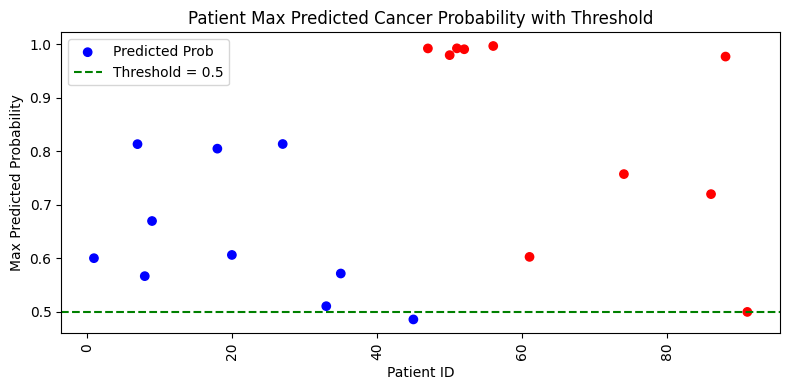

In [ ]:
patient_pred_proba = test_df_copy.groupby('Patient ID')['Predicted_Prob_Cancer'].max()
patient_pred_label = test_df_copy.groupby('Patient ID')['Predicted_Label'].apply(lambda x: x.mode()[0])
patient_final_decision = (patient_pred_proba >= 0.7250).astype(int)


patient_true_label = test_df_copy.groupby('Patient ID')['Label'].max()

# add all to 1 df
patient_results = pd.DataFrame({
    'Predicted_Label_MajorityVote': patient_pred_label,
    'Predicted_Prob_Max': patient_pred_proba,
    'Final_Decision_by_Prob_Threshold': patient_final_decision,
    'True_Label': patient_true_label
})

print("Patient-level Accuracy:", accuracy_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))
print("Patient-level Precision:", precision_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))
print("Patient-level Recall:", recall_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))
print("Patient-level F1:", f1_score(patient_results['True_Label'], patient_results['Final_Decision_by_Prob_Threshold']))



plt.figure(figsize=(8,4))
plt.scatter(patient_results.index, patient_results['Predicted_Prob_Max'],
            c=patient_results['True_Label'], cmap='bwr', label='Predicted Prob')
plt.axhline(0.7, color='green', linestyle='--', label='Threshold = 0.7')
plt.xlabel('Patient ID')
plt.ylabel('Max Predicted Probability')
plt.title('Patient Max Predicted Cancer Probability with Threshold')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Conclusion and Results

By grouping predictions at the patient level and choosing the best probability threshold, we improve classification accuracy. Using the maximum predicted cancer probability per patient ensures that even one highly suspicious sample flags the patient as positive. Optimizing the threshold with F1 score balances precision and recall, resulting in a patient-level F1 score of around 0.7, which shows a good balance between detecting true positives and minimizing false alarms. This approach leads to more reliable cancer detection than fixed thresholds or single-sample predictions.